# Toxic Comments Classification - BiLSTM

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: JigsawToxic dataset is a dataset of comments from Wikipedia’s talk page edits. It is avaialble at Kaggle (https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data). 


The comments are divided in two classes: toxic and normal.

Algorithme used: BiLSTM

Preprocessing techniques used:
* Lowercase
* Remove frequent words
* Remove stop words
* Tokenization (accept all kind of tokens except spaces (carriage returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle, time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, accuracy_score, recall_score, f1_score, precision_score
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.model_selection import GridSearchCV,KFold
from sklearn.preprocessing import StandardScaler
from keras.wrappers.scikit_learn import KerasClassifier
from keras.layers import Dense, Input, Dropout
from keras import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.preprocessing import text
import re
from nltk.corpus import stopwords
from datetime_extractor import DateTimeExtractor

from tensorflow.keras.layers import Dense, Embedding,GlobalMaxPooling1D, GlobalMaxPool1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, LSTM
from tensorflow.keras.layers import Embedding
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import to_categorical

import seaborn as sns
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side

# 2. Data Preparation 

In [2]:
# Load training data
df = pd.read_csv('../../Data/train_set3.csv')
df.head()

,Tweet ID,Text,tox
0,1230482808457527297,BREAKING: Many leading Chinese scientists are ...,0.0
1,1244980592615116800,"If China can kill us, they can kill you too @A...",1.0
2,1244899032771604480,Fuck u Chi Na!!! Karma is coming soon !!! The ...,1.0
3,1244895530720710656,Some Chinese are horrible as fuck! #ChinaLiedP...,1.0
4,1244341105879142407,"@ScottGottliebMD you are a ""doctor"" and you be...",1.0


In [3]:
# Load testing data
test = pd.read_csv('../../Data/test_set3.csv')
test.head()

,Tweet ID,Text,tox
0,1230469201325895691,@BangizweNkosi @alfred_cabonena #Commies the s...,1.0
1,1245286806330806273,@LeeooZeng @ChinaDaily Mother Fucking #chinese...,1.0
2,1245502582593912833,@argyleumbrella @business Yep. Fucking MONTHS ...,1.0
3,1230388499792220163,To all the Xbots that couldn’t control your fa...,0.0
4,1241063784501915648,@realDonaldTrump This is the most racist and u...,0.0


# 3. Preprocessing

In [4]:
stop_words = set(stopwords.words('english'))

In [5]:
print(stop_words)

{'few', 'don', "haven't", "weren't", 've', 'wasn', 'is', 'wouldn', 'where', 'they', 'he', 's', 'this', 'do', 'very', 'above', "mightn't", 't', 'what', 'who', 'off', "couldn't", 'same', 'any', 'nor', 'with', 'isn', "it's", 'whom', 'into', 'didn', "isn't", 'did', 'it', 'am', 'needn', 'we', 'won', 'yourself', 'the', 'once', "wouldn't", 'can', "should've", 'their', 'which', 'these', 'themselves', 'more', "shouldn't", 'out', "doesn't", 'himself', 'had', 'own', 'too', 'ain', "wasn't", 'him', 'hadn', "won't", 'she', "she's", 'aren', 'your', 'or', 'by', 'here', 'have', 'are', 'yourselves', 'after', 'most', 'over', "that'll", 'again', 'itself', 'at', 'on', 'mustn', 'all', 'hers', "you'd", "needn't", 'so', 'ma', 'a', 'doing', 'will', 'down', 'than', 'before', 'under', "don't", 'doesn', 'for', 'during', 'o', 'ours', 'how', "hasn't", 'up', 'myself', 'yours', 'if', 'because', 'some', 'haven', 'couldn', 'not', 'that', 'when', 'm', 'i', 'and', 'them', 'but', 'of', 'you', 'an', "you've", "aren't", "yo

In [6]:
def convert_lowercase(comment): 

    comment = comment.lower() # Normalize to lowercase 
    
    return comment

In [7]:
# clean and normalize comments
df['Text'] = df['Text'].map(lambda word:convert_lowercase(word))
test['Text'] = test['Text'].map(lambda word:convert_lowercase(word))

In [8]:
# find the 10 most frequent words in the train data
dellist1 = pd.Series(' '.join(df['Text']).split()).value_counts()[1:10]
print(dellist1)

to         1167
and         944
of          824
a           786
is          781
chinese     635
you         622
in          606
china       502
dtype: int64


In [9]:
# remove the most frequent words from the train data
dellist1 = list(dellist1.index)
df['Text'] = df['Text'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist1))
df.head()

,Tweet ID,Text,tox
0,1230482808457527297,breaking: many leading scientists are starting...,0.0
1,1244980592615116800,"if can kill us, they can kill too @angusch8961...",1.0
2,1244899032771604480,fuck u chi na!!! karma coming soon !!! the ccp...,1.0
3,1244895530720710656,some are horrible as fuck! #chinaliedpeopledie...,1.0
4,1244341105879142407,"@scottgottliebmd are ""doctor"" believe that shi...",1.0


In [10]:
# find the 10 most frequent words in the test data
dellist2 = pd.Series(' '.join(test['Text']).split()).value_counts()[1:10]
print(dellist2)

to         294
and        212
of         211
is         210
a          199
chinese    172
in         160
you        147
are        128
dtype: int64


In [11]:
# remove the most frequent words from the test data
dellist2 = list(dellist2.index)
test['Text'] = test['Text'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist2))
test.head()

,Tweet ID,Text,tox
0,1230469201325895691,@bangizwenkosi @alfred_cabonena #commies the s...,1.0
1,1245286806330806273,@leeoozeng @chinadaily mother fucking #chinese...,1.0
2,1245502582593912833,@argyleumbrella @business yep. fucking months ...,1.0
3,1230388499792220163,all the xbots that couldn’t control your fanbo...,0.0
4,1241063784501915648,@realdonaldtrump this the most racist unprofes...,0.0


In [12]:
def clean_text(comment): 

    word_tokens = comment.split(' ') #word_tokenize(comment)
    
    filtered_comment = []  
    # converts the words in word_tokens tand tchecks whether 
    #they are present in stop_words or not
    for w in word_tokens:
        if w not in stop_words:
            filtered_comment.append(w)

    comment = (" ").join(filtered_comment)
    
    return comment

In [13]:
# clean and normalize comments
df['Text'] = df['Text'].map(lambda word:clean_text(word))
test['Text'] = test['Text'].map(lambda word:clean_text(word))

In [14]:
x_train, x_val, y_train, y_val = train_test_split(df['Text'], df['tox'], test_size=0.15, random_state=42)

In [15]:
#Check shape of train data
print(x_train.shape)
print(y_train.shape)

(1788,)
(1788,)


In [16]:
#Check shape of validation data
print(x_val.shape)
print(y_val.shape)

(316,)
(316,)


In [17]:
x_test = test['Text']
y_test = test['tox']

#Check shape of data
print(x_test.shape)
print(y_test.shape)

(527,)
(527,)


### Vectorize texts

In [18]:
# Create vocabulary with training texts.
tokenizer = text.Tokenizer(num_words=20000, filters='\r\t\n', lower=False)  # Limit on the number of features. We use the top 20K features.
tokenizer.fit_on_texts(list(x_train)+ list(x_val) + list(x_test))

# Vectorize training texts.
tokenized_train = tokenizer.texts_to_sequences(x_train)
tokenized_val = tokenizer.texts_to_sequences(x_val)
tokenized_test = tokenizer.texts_to_sequences(x_test)

In [19]:
# Limit on the length of text sequences. Sequences longer than this
# will be truncated.
MAX_SEQUENCE_LENGTH = 100


# Get max sequence length.
max_length = len(max(x_train, key=len))
if max_length > MAX_SEQUENCE_LENGTH:
       max_length = MAX_SEQUENCE_LENGTH

In [20]:
# Fix sequence length to max value. Sequences shorter than the length are
# padded in the end and sequences longer are truncated
# at the end.
X_train = pad_sequences(tokenized_train, maxlen=max_length, padding= 'post')
X_val = pad_sequences(tokenized_val, maxlen=max_length, padding= 'post')
X_test = pad_sequences(tokenized_test, maxlen=max_length, padding= 'post')

In [21]:
# Get length of corpus's word index
vocab_size=(len(tokenizer.word_index)+1)
print(vocab_size)

11339


###  converts a class vector (integers) to binary class matrix.

In [22]:
# converts a class vector (integers) to binary class matrix.
Y_train=to_categorical(y_train)
#Check shape of data
Y_train.shape

(1788, 2)

In [23]:
# converts a class vector (integers) to binary class matrix.
Y_val=to_categorical(y_val)
#Check shape of data
Y_val.shape

(316, 2)

In [24]:
# converts a class vector (integers) to binary class matrix.
Y_test=to_categorical(y_test)
#Check shape of data
Y_test.shape

(527, 2)

In [25]:
Y_val[:2]

array([[0., 1.],
       [0., 1.]], dtype=float32)

In [26]:
Y_test[:2]

array([[0., 1.],
       [0., 1.]], dtype=float32)

In [27]:
Y_train[:2]

array([[1., 0.],
       [0., 1.]], dtype=float32)

# 3. Create model

In [28]:
EMBEDDING_DIM=400

def model_to_optimize(optimizer='RMSprop'): #learning_rate = 0.001 default value
         
    model = Sequential()
    
    seq = Input(shape=(max_length,))
    input_seq = Embedding(
        input_dim = vocab_size, input_length = max_length,output_dim = EMBEDDING_DIM)(seq)
    
    layer = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))(input_seq)
    layer = GlobalMaxPool1D()(layer)
    output = Dense(2, activation='softmax')(layer) 
        
    model = Model(inputs=seq, outputs=output)
        
    model.compile(loss='binary_crossentropy',optimizer=optimizer, metrics=['accuracy'])
    return model

In [29]:
from keras import backend, Model

model_used = model_to_optimize()
# summarize model
model_used.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 100)]             0         
_________________________________________________________________
embedding (Embedding)        (None, 100, 400)          4535600   
_________________________________________________________________
bidirectional (Bidirectional (None, 100, 128)          238080    
_________________________________________________________________
global_max_pooling1d (Global (None, 128)               0         
_________________________________________________________________
dense (Dense)                (None, 2)                 258       
Total params: 4,773,938
Trainable params: 4,773,938
Non-trainable params: 0
_________________________________________________________________


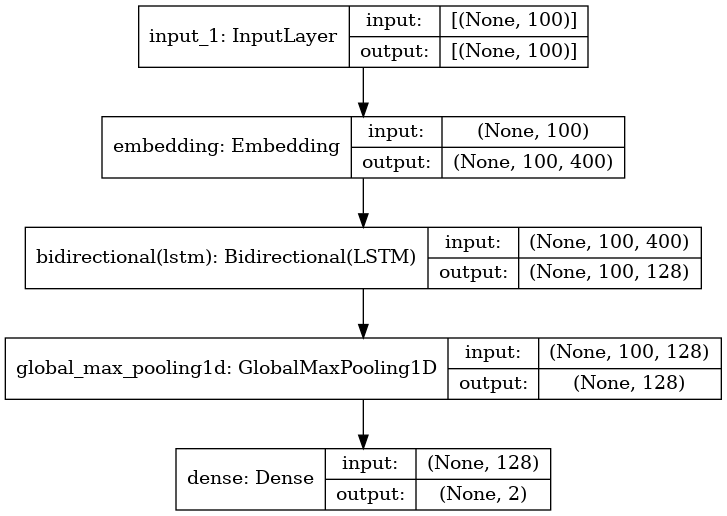

In [30]:
# plot model
plot_model(model_used, show_shapes=True)

In [31]:
## Define your callbacks
Modle_Checkpoint = ModelCheckpoint(
    'models/bilstm_approach#10.h5',
    monitor='val_loss',
    save_best_only='True',
    mode='min',
    verbose=1
)

Early_Stopping = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    verbose=1,
    restore_best_weights='True',
    min_delta=0
)

In [32]:
callbacks = [Early_Stopping, Modle_Checkpoint, ]

### Train classifier

In [33]:
history = model_used.fit(X_train,Y_train, epochs=100,
                            callbacks=callbacks,
                            batch_size=128, #litterature review
                            validation_data=(X_val, Y_val),
                            verbose=True)

Epoch 1/100
14/14 [==============================] - 20s 1s/step - loss: 0.6771 - accuracy: 0.6275 - val_loss: 0.6277 - val_accuracy: 0.8481

Epoch 00001: val_loss improved from inf to 0.62768, saving model to models/bilstm_approach#10.h5
Epoch 2/100
14/14 [==============================] - 15s 1s/step - loss: 0.4324 - accuracy: 0.8781 - val_loss: 0.4469 - val_accuracy: 0.8101

Epoch 00002: val_loss improved from 0.62768 to 0.44688, saving model to models/bilstm_approach#10.h5
Epoch 3/100
14/14 [==============================] - 16s 1s/step - loss: 0.1921 - accuracy: 0.9200 - val_loss: 0.3184 - val_accuracy: 0.8544

Epoch 00003: val_loss improved from 0.44688 to 0.31837, saving model to models/bilstm_approach#10.h5
Epoch 4/100
14/14 [==============================] - 15s 1s/step - loss: 0.0977 - accuracy: 0.9692 - val_loss: 0.2883 - val_accuracy: 0.8797

Epoch 00004: val_loss improved from 0.31837 to 0.28832, saving model to models/bilstm_approach#10.h5
Epoch 5/100
14/14 [=============

### Evaluate metrics

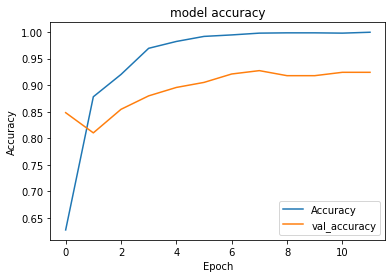

In [34]:
import matplotlib.pyplot as plt
hist = history.history
plt.plot(hist["accuracy"])
plt.plot(hist['val_accuracy'])
plt.title("model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy","val_accuracy"])
plt.show()

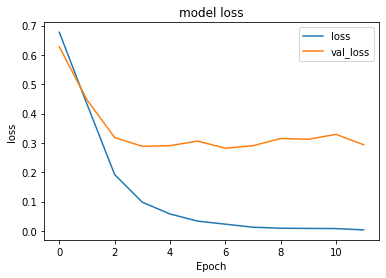

In [35]:
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("Epoch")
plt.legend(["loss","val_loss"])
plt.show()

In [36]:
from keras.models import load_model
saved_model = load_model("models/bilstm_approach#10.h5")

result = saved_model.evaluate(X_train,Y_train,
                               batch_size=128, #litterature review
                            verbose=True)


14/14 [==============================] - 3s 170ms/step - loss: 0.0154 - accuracy: 0.9972


In [37]:
print("train loss: %0.3f" % result[0])
print("train acc: %0.3f" % result[1])

train loss: 0.015
train acc: 0.997


In [38]:
result_val = saved_model.evaluate(X_val,Y_val,
                               batch_size=128, #litterature review
                            verbose=True)

3/3 [==============================] - 0s 151ms/step - loss: 0.2819 - accuracy: 0.9209


In [39]:
print("validation loss: %0.3f" % result_val[0])
print("validation acc: %0.3f" % result_val[1])

validation loss: 0.282
validation acc: 0.921


In [40]:
train_accuracy = "%.4f" % (result[1])
train_Loss = r"%.4f" % (result[0])
val_accuracy = "%.4f" % (result_val[1])
val_loss = "%.4f" % (result_val[0])

# 4. Predictions

### Test set

In [41]:
y_pred=saved_model.predict(X_test, batch_size=128, verbose=True)

5/5 [==============================] - 1s 149ms/step


In [42]:
print(y_pred)

[[2.3635106e-05 9.9997640e-01]
 [2.2684562e-04 9.9977320e-01]
 [1.7173740e-03 9.9828267e-01]
 ...
 [3.4705867e-05 9.9996531e-01]
 [8.4659136e-05 9.9991536e-01]
 [2.2263161e-05 9.9997771e-01]]


In [43]:
print(Y_train)

[[1. 0.]
 [0. 1.]
 [0. 1.]
 ...
 [0. 1.]
 [1. 0.]
 [0. 1.]]


In [44]:
print(Y_test)

[[0. 1.]
 [0. 1.]
 [0. 1.]
 ...
 [0. 1.]
 [0. 1.]
 [0. 1.]]


In [45]:
print("\n Accuracy: %0.2f" % accuracy_score(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)))
print("\n Confusion matrix\n")
print(classification_report(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)))


 Accuracy: 0.92

 Confusion matrix

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       263
           1       0.90      0.94      0.92       264

    accuracy                           0.92       527
   macro avg       0.92      0.92      0.92       527
weighted avg       0.92      0.92      0.92       527



In [46]:
y_pred=np.argmax(y_pred, axis=1)
Y_test=np.argmax(Y_test, axis=1)
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[236  27]
 [ 17 247]]


In [47]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, y_pred))
test_recall  = "%.4f" % (recall_score(Y_test, y_pred))
test_F1_score  = "%.4f" % (f1_score(Y_test, y_pred))
test_precision  = "%.4f" % (precision_score(Y_test, y_pred))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.9165
recall :  0.9356
F1_score :  0.9182
precision :  0.9015


# 5. Save results to Excel file

In [48]:
# define tarjet
newFile = "../results_BiLSTM_set3.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #10', 2:train_accuracy, 3:train_Loss, 4:val_accuracy, 5:val_loss, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach#1
index = 12

# delete row of approach#1
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)